# **Problem Statement :**
## Design and develop a machine learning system that predicts the annual salary (in USD) of AI and data-related job postings using job characteristics, experience level, education, company attributes, geographic location, benefits, and remote-work information.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

# 1. Load the Dataset


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Project_Datasets/num_cat_Dataset/ai_job_dataset.csv")
df.shape

(15000, 19)

## 2. Explore The Data


In [ ]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [ ]:
# let us Drop COlumns "job_id","salary_currency","required_skills","company_name","posting_date","application_deadline" these columns are not important for model building
df=df.drop(columns=["job_id","salary_currency","required_skills","company_name","posting_date","application_deadline" ])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_title               15000 non-null  object 
 1   salary_usd              15000 non-null  int64  
 2   experience_level        15000 non-null  object 
 3   employment_type         15000 non-null  object 
 4   company_location        15000 non-null  object 
 5   company_size            15000 non-null  object 
 6   employee_residence      15000 non-null  object 
 7   remote_ratio            15000 non-null  int64  
 8   education_required      15000 non-null  object 
 9   years_experience        15000 non-null  int64  
 10  industry                15000 non-null  object 
 11  job_description_length  15000 non-null  int64  
 12  benefits_score          15000 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.5+ MB


In [ ]:
# Let us check Missing Values
df.isnull().sum()/len(df)*100

,0
job_title,0.0
salary_usd,0.0
experience_level,0.0
employment_type,0.0
company_location,0.0
company_size,0.0
employee_residence,0.0
remote_ratio,0.0
education_required,0.0
years_experience,0.0


In [ ]:
# Let us identify the Duplicate values
df.duplicated().sum()

np.int64(0)

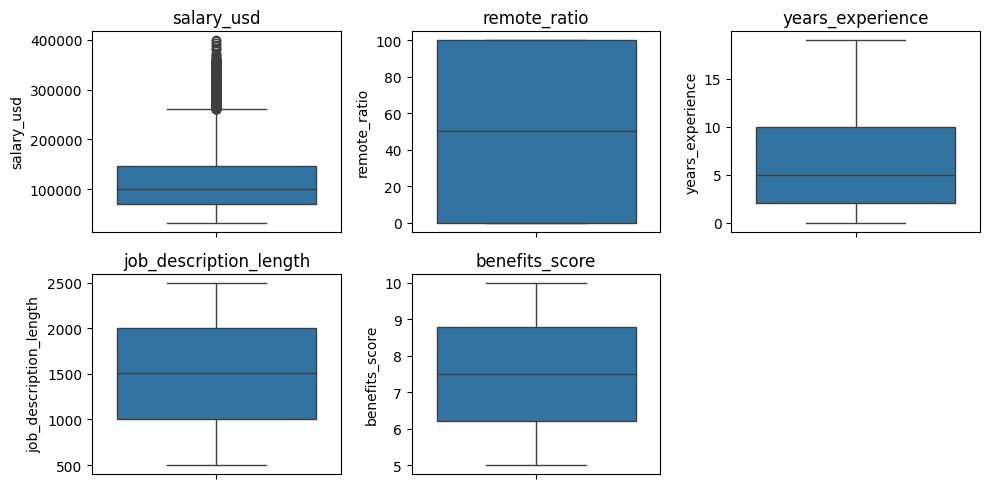

In [ ]:
# Let us check the Distribution of numerical columns
num_cols=df.select_dtypes(include="number").columns
plt.figure(figsize=(10,5))
for i,col in enumerate(num_cols,1):
  plt.subplot(2,3,i)
  sns.boxplot(df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

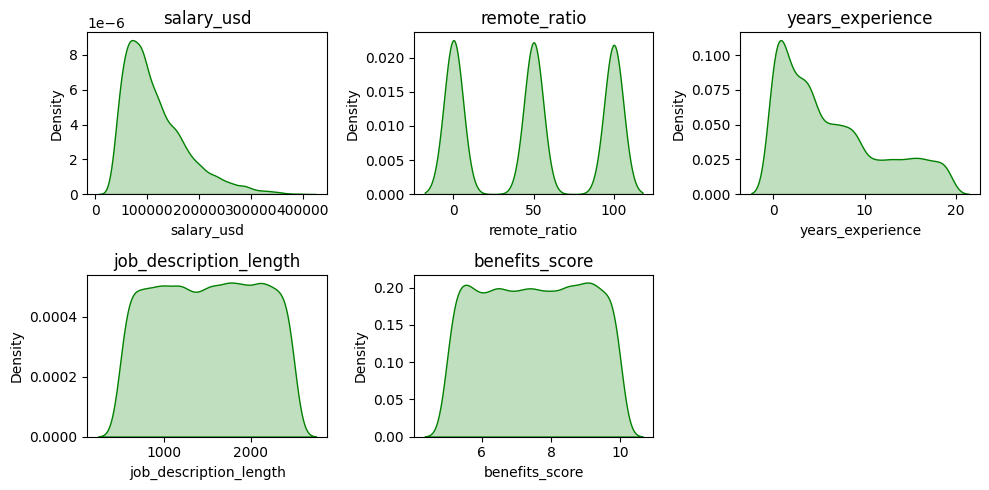

In [ ]:
# Let us check the Distribution of numerical columns
plt.figure(figsize=(10,5))
for i,col in enumerate(num_cols,1):
  plt.subplot(2,3,i)
  sns.kdeplot(df[col],fill=True,color='green')
  plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_title               15000 non-null  object 
 1   salary_usd              15000 non-null  int64  
 2   experience_level        15000 non-null  object 
 3   employment_type         15000 non-null  object 
 4   company_location        15000 non-null  object 
 5   company_size            15000 non-null  object 
 6   employee_residence      15000 non-null  object 
 7   remote_ratio            15000 non-null  int64  
 8   education_required      15000 non-null  object 
 9   years_experience        15000 non-null  int64  
 10  industry                15000 non-null  object 
 11  job_description_length  15000 non-null  int64  
 12  benefits_score          15000 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.5+ MB


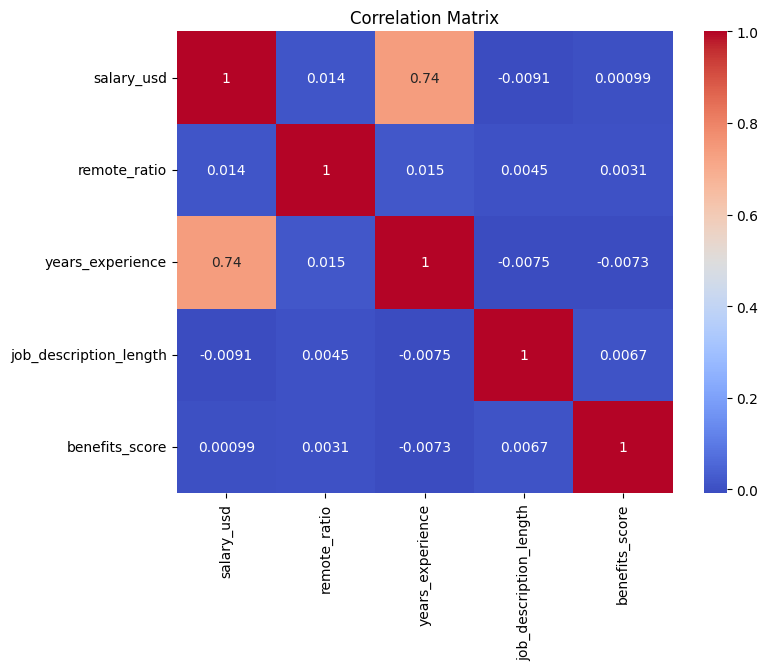

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'salary_usd',
    'remote_ratio',
    'years_experience',
    'job_description_length',
    'benefits_score'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


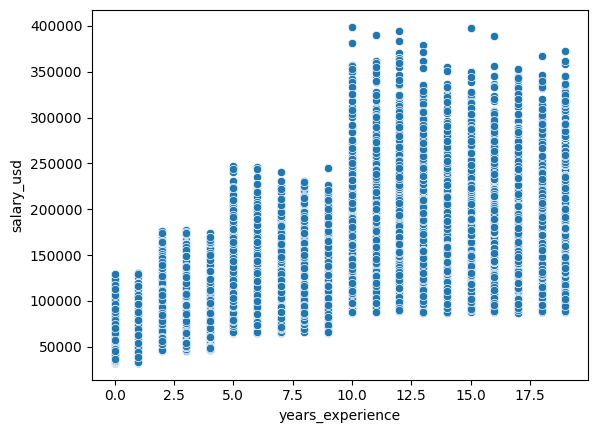

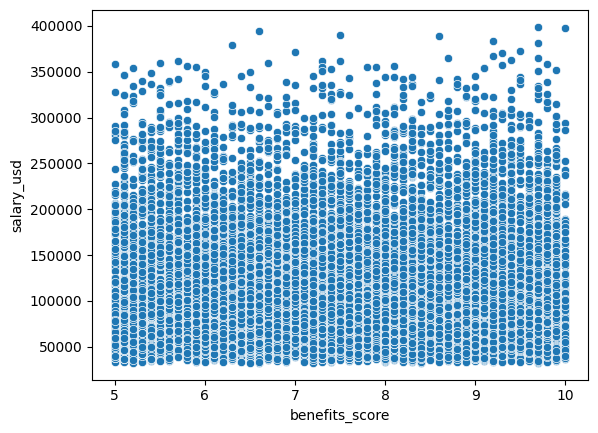

In [ ]:
sns.scatterplot(x='years_experience', y='salary_usd', data=df)
plt.show()

sns.scatterplot(x='benefits_score', y='salary_usd', data=df)
plt.show()


### **1. Salary increases strongly with years of experience, confirming it as the most influential numerical predictor.**
### **2. Benefits score does not directly influence base salary and shows no predictive pattern.**

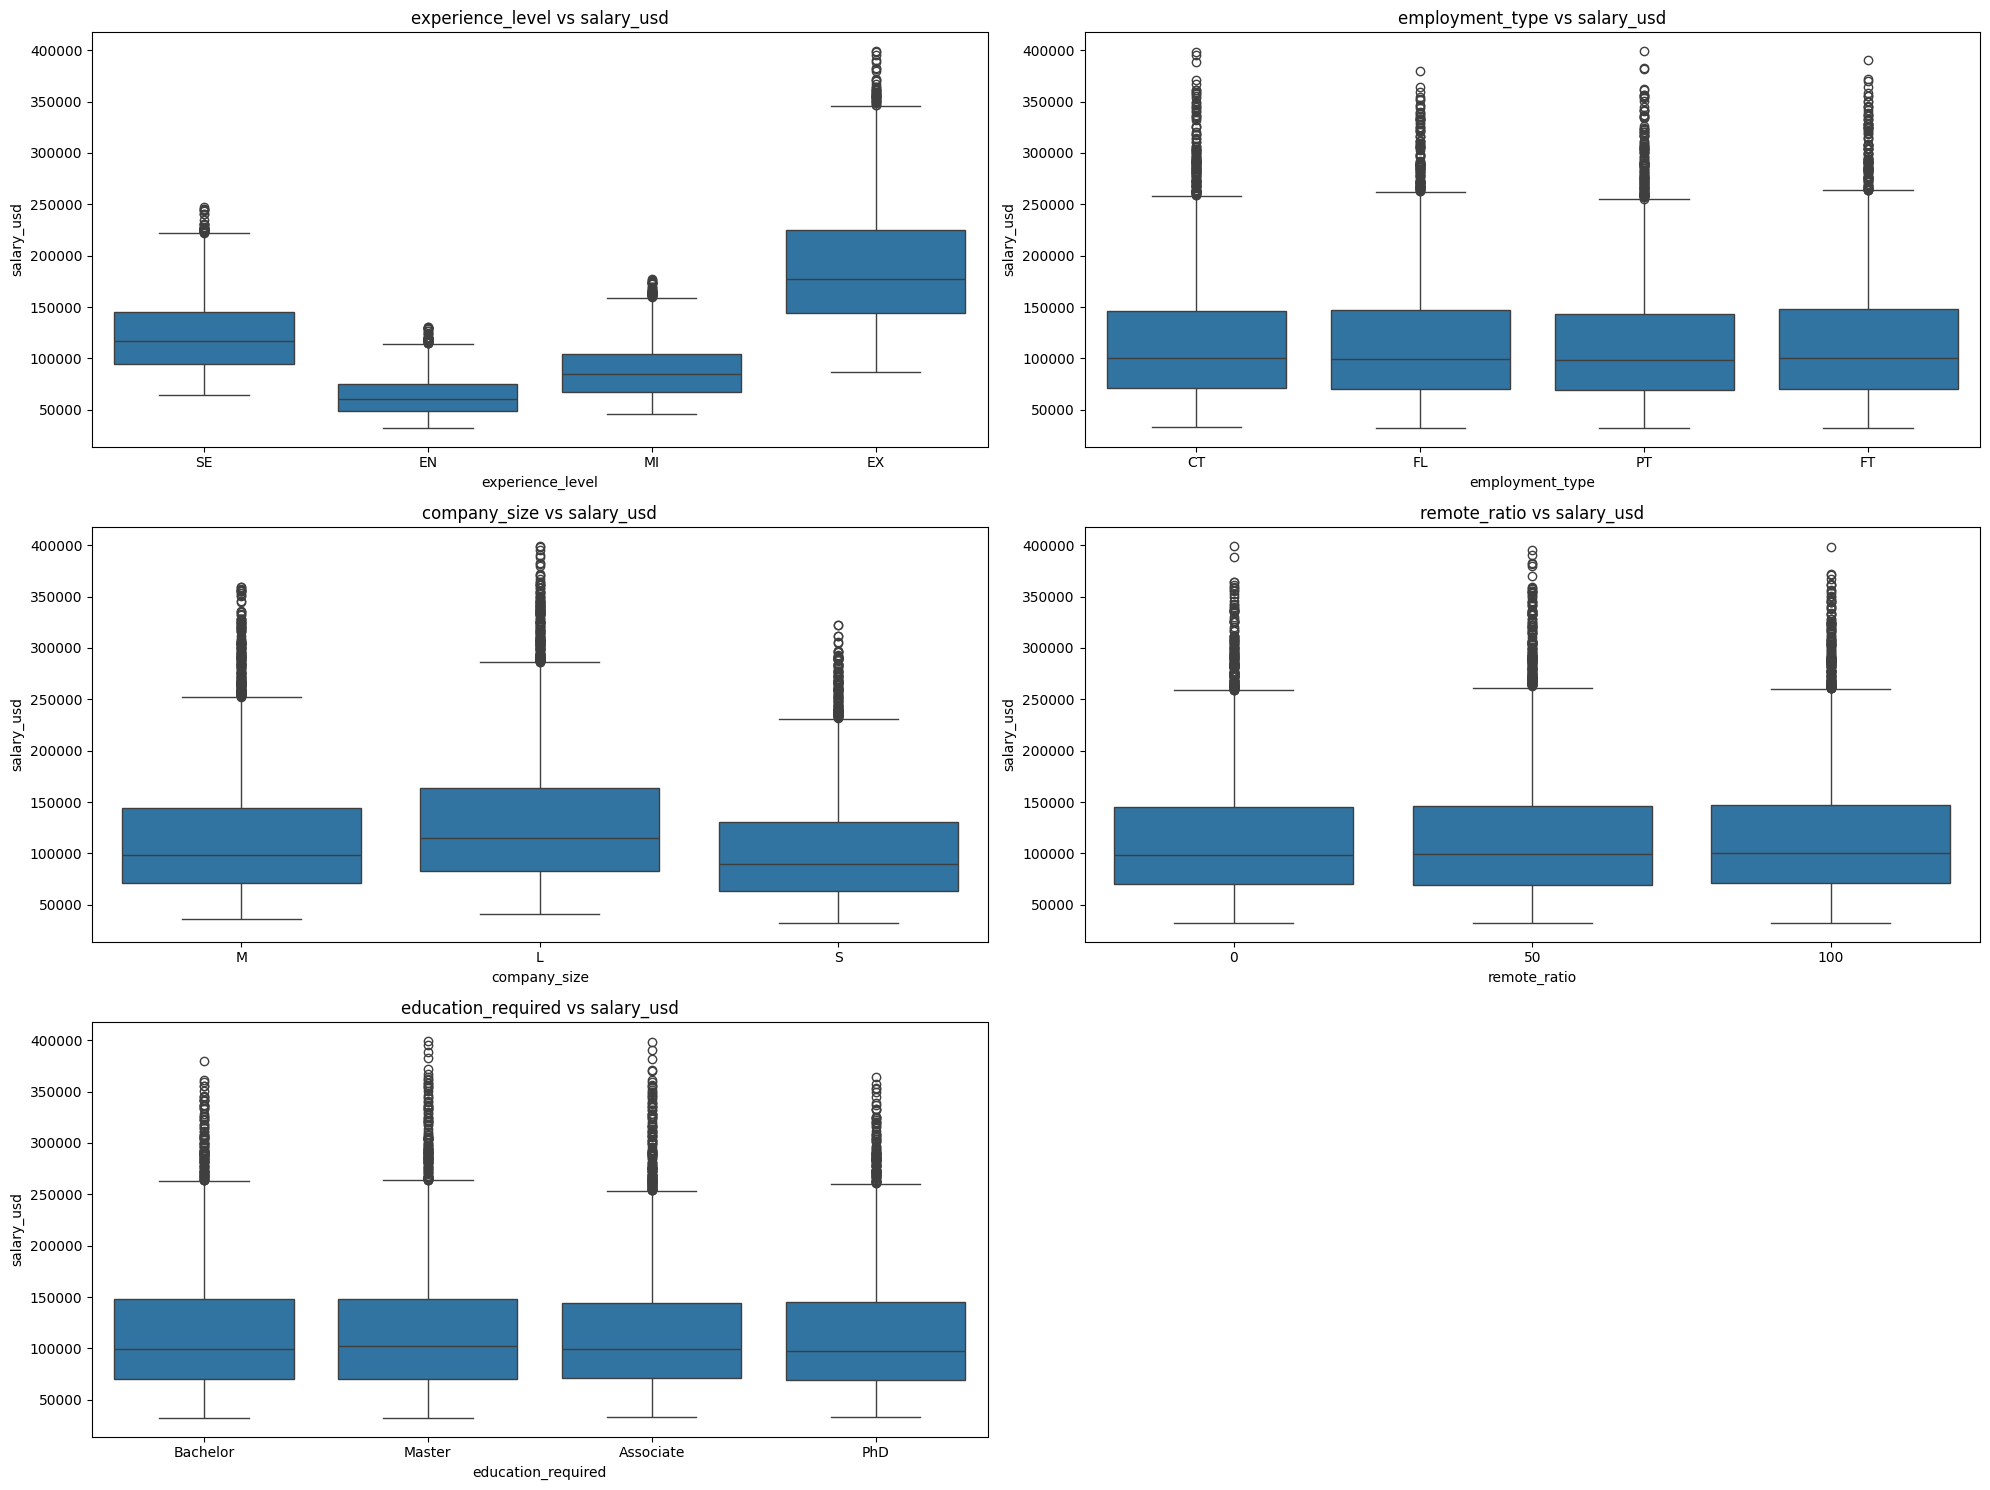

In [ ]:
plt.figure(figsize=(20,15))
cat_cols=['experience_level','employment_type','company_size','remote_ratio','education_required']
for i,col in enumerate(cat_cols,1):
  plt.subplot(3,2,i)
  sns.boxplot(x=col,y='salary_usd',data=df)
  plt.title(f"{col} vs salary_usd")
plt.tight_layout()
plt.show()

### **1. Experience level causes clear salary jumps and is a critical categorical feature.**
### **2. Employment type has minimal impact on salary compared to experience or role.**
### **3. Company size significantly influences salary, with large organizations paying more.**
### **4. Remote work percentage does not significantly impact salary on its own.**
### **5. Education level alone does NOT strongly separate salary.**

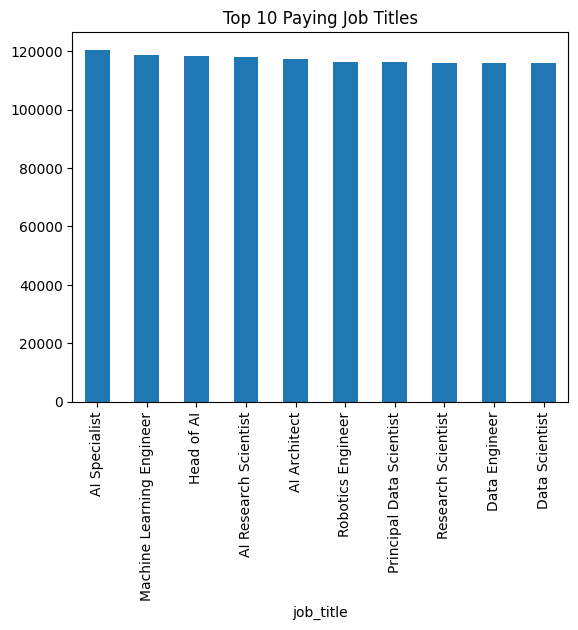

In [ ]:
top_jobs = df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False).head(10)
top_jobs.plot(kind='bar', title='Top 10 Paying Job Titles')
plt.show()


## **Job title is one of the strongest salary differentiators but has high cardinality.**

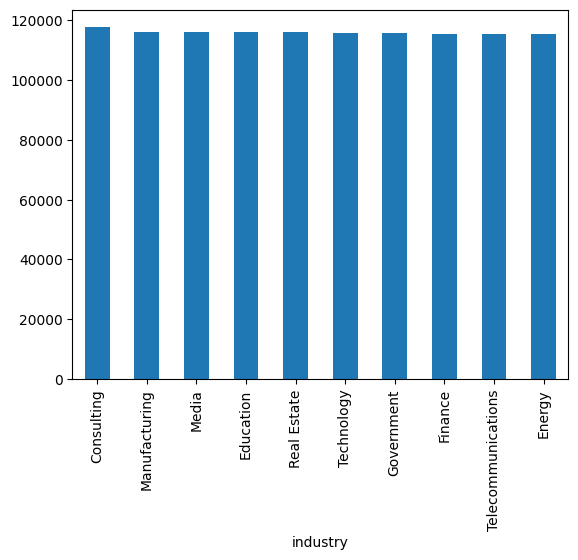

In [ ]:
industry_salary = df.groupby('industry')['salary_usd'].mean().sort_values(ascending=False)
industry_salary.head(10).plot(kind='bar')
plt.show()


### **Industry impacts salary but less than job title or experience.**

## **Salary prediction is driven primarily by experience, role, company size, and industry, while job benefits, job description length, and remote work percentage do not significantly influence base salary.Therefore, the model will focus on experience-based and role-based features, supported by relevant organizational attributes.**

In [ ]:
# Let us drop 'job_description_length','benefits_score' columns where these do not significantly influence base salary
df=df.drop(columns=['job_description_length','benefits_score'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           15000 non-null  object
 1   salary_usd          15000 non-null  int64 
 2   experience_level    15000 non-null  object
 3   employment_type     15000 non-null  object
 4   company_location    15000 non-null  object
 5   company_size        15000 non-null  object
 6   employee_residence  15000 non-null  object
 7   remote_ratio        15000 non-null  int64 
 8   education_required  15000 non-null  object
 9   years_experience    15000 non-null  int64 
 10  industry            15000 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.3+ MB


In [ ]:
for i in num_cols:
  print(i,":",df[i].nunique())

salary_usd : 14315
remote_ratio : 3
years_experience : 20
job_description_length : 2000
benefits_score : 51


In [ ]:
# Identifying Target Variable
y=df['salary_usd']
# Let us Select Input Varibles
X=df.drop(columns="salary_usd")

# 3. Spliting Data into Testing and Training sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=99)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12000, 10)
(3000, 10)
(12000,)
(3000,)


# 4. Data Preprocessing

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   job_title           15000 non-null  object
 1   experience_level    15000 non-null  object
 2   employment_type     15000 non-null  object
 3   company_location    15000 non-null  object
 4   company_size        15000 non-null  object
 5   employee_residence  15000 non-null  object
 6   remote_ratio        15000 non-null  int64 
 7   education_required  15000 non-null  object
 8   years_experience    15000 non-null  int64 
 9   industry            15000 non-null  object
dtypes: int64(2), object(8)
memory usage: 1.1+ MB


In [ ]:
df['employment_type'].unique()

array(['CT', 'FL', 'PT', 'FT'], dtype=object)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
ordinal_categories = [
    ["EN", "MI", "SE", "EX"], # experience_level
    ["S", "M", "L"],         # company_size
    ["High School", "Associate", "Bachelor", "Master", "PhD"] # education_required
]
transformer=ColumnTransformer(transformers=[("t1",OrdinalEncoder(categories=ordinal_categories), [1,4,7]),
                                            ("t2",OrdinalEncoder(),[0,2,3,5,9])],
                                            remainder="passthrough")
X_train_trans=transformer.fit_transform(X_train)
X_test_trans=transformer.transform(X_test)

In [ ]:
X_train_trans=pd.DataFrame(X_train_trans,columns=transformer.get_feature_names_out())
X_test_trans=pd.DataFrame(X_test_trans,columns=transformer.get_feature_names_out())
X_train_trans.head()

,t1__experience_level,t1__company_size,t1__education_required,t2__job_title,t2__employment_type,t2__company_location,t2__employee_residence,t2__industry,remainder__remote_ratio,remainder__years_experience
0,1.0,2.0,1.0,6.0,1.0,3.0,3.0,3.0,100.0,2.0
1,0.0,1.0,1.0,14.0,0.0,4.0,4.0,6.0,50.0,0.0
2,0.0,1.0,3.0,16.0,1.0,3.0,3.0,9.0,0.0,0.0
3,2.0,1.0,3.0,19.0,2.0,11.0,11.0,9.0,50.0,5.0
4,0.0,1.0,1.0,13.0,1.0,4.0,4.0,11.0,50.0,0.0


In [ ]:
X_test_trans.head()

,t1__experience_level,t1__company_size,t1__education_required,t2__job_title,t2__employment_type,t2__company_location,t2__employee_residence,t2__industry,remainder__remote_ratio,remainder__years_experience
0,3.0,2.0,4.0,14.0,2.0,4.0,4.0,13.0,100.0,11.0
1,1.0,0.0,4.0,10.0,0.0,17.0,17.0,1.0,100.0,4.0
2,1.0,2.0,2.0,9.0,2.0,15.0,1.0,7.0,50.0,2.0
3,2.0,1.0,2.0,4.0,3.0,3.0,3.0,12.0,100.0,9.0
4,0.0,1.0,1.0,6.0,1.0,8.0,8.0,5.0,0.0,1.0


# 5. **Model Building**

# 1. KNN Regressor Model

## HyperParameter Tuning

In [ ]:
# Grid Search
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
tuned_params={'n_neighbors':[i for i in range(1,41)],'p':[1,2,3]}
knn_grid=GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=tuned_params,
    scoring="r2",
    return_train_score=True,
    verbose=0
)
knn_grid.fit(X_train_trans,y_train)

KeyboardInterrupt: 

In [ ]:
print("Best Estimator:",knn_grid.best_estimator_)
print("Best KNN Regression Metrics:",knn_grid.best_params_)
print("Best KNN R2-score:",knn_grid.best_score_)

In [ ]:
# Random Search
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
tuned_params={'n_neighbors':[i for i in range(1,41)],'p':[1,2,3]}
knn_random=RandomizedSearchCV(
    estimator=KNeighborsRegressor(),
    param_distributions=tuned_params,
    scoring="r2",
    return_train_score=True,
    verbose=0
)
knn_random.fit(X_train_trans,y_train)

RandomizedSearchCV(estimator=KNeighborsRegressor(),
                   param_distributions={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8,
                                                        9, 10, 11, 12, 13, 14,
                                                        15, 16, 17, 18, 19, 20,
                                                        21, 22, 23, 24, 25, 26,
                                                        27, 28, 29, 30, ...],
                                        'p': [1, 2, 3]},
                   return_train_score=True, scoring='r2')

In [ ]:
print("Best Estimator:",knn_random.best_estimator_)
print("Best KNN Regression Metrics:",knn_random.best_params_)
print("Best KNN R2-score:",knn_random.best_score_)

Best Estimator: KNeighborsRegressor(n_neighbors=10, p=1)
Best KNN Regression Metrics: {'p': 1, 'n_neighbors': 10}
Best KNN R2-score: 0.7054757398937113


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
knn_model=make_pipeline(transformer,KNeighborsRegressor(n_neighbors=11,p=1))
knn_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('kneighborsregressor',
                 KNeighborsRegressor(n_neighbors=11, p=1))])

In [ ]:
y_pred_knn=knn_model.predict(X_test)
print(y_pred_knn.shape)
y_train_pred_knn=knn_model.predict(X_train)
print(y_train_pred_knn.shape)
print(y_test.shape)

(3000,)
(12000,)
(3000,)


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
knn_score=r2_score(y_test,y_pred_knn)
knn_train_score=r2_score(y_train,y_train_pred_knn)
knn_mae=mean_absolute_error(y_test,y_pred_knn)
knn_mse=mean_squared_error(y_test,y_pred_knn)
knn_rmse=root_mean_squared_error(y_test,y_pred_knn)
print("Test R2-score for KNN Model :",knn_score)
print("Train R2-score for KNN Model :",knn_train_score)

print("Mean Absolute Error:",knn_mae)
print("Mean Squared Error:",knn_mse)
print("Root Mean Squared Error:",knn_rmse)

Test R2-score for KNN Model : 0.7037241105630418
Train R2-score for KNN Model : 0.7626796510668439
Mean Absolute Error: 23074.33551515151
Mean Squared Error: 1083096930.8195207
Root Mean Squared Error: 32910.43802229804


# 2. Decision Tree Model Building

# HyperParameter Tuning


In [ ]:
# Grid Search
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
tuned_params = {
    'max_depth': range(2, 30),
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 15),
    'max_features': ['sqrt','log2',None]
}
dt_grid=GridSearchCV(
    estimator=DecisionTreeRegressor(),
    param_grid=tuned_params,

    scoring="r2",
    return_train_score=True,
    verbose=0
)
dt_grid.fit(X_train_trans,y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': range(2, 30),
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': range(1, 15),
                         'min_samples_split': range(2, 20)},
             return_train_score=True, scoring='r2')

In [ ]:
print("Best Estimator:",dt_grid.best_estimator_)
print("Best KNN Regression Metrics:",dt_grid.best_params_)
print("Best KNN R2-score:",dt_grid.best_score_)

Best Estimator: DecisionTreeRegressor(max_depth=10, min_samples_leaf=14)
Best KNN Regression Metrics: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 14, 'min_samples_split': 2}
Best KNN R2-score: 0.8771758758597625


In [ ]:
# Random Search
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor
tuned_params = {
    'max_depth': range(2, 30),
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 15),
    'max_features': ['sqrt','log2',None]
}
dt_random=RandomizedSearchCV(
    estimator=DecisionTreeRegressor(),
    param_distributions=tuned_params,
    scoring="r2",
    return_train_score=True,
    verbose=0
)
dt_random.fit(X_train_trans,y_train)

RandomizedSearchCV(estimator=DecisionTreeRegressor(),
                   param_distributions={'max_depth': range(2, 30),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': range(1, 15),
                                        'min_samples_split': range(2, 20)},
                   return_train_score=True, scoring='r2')

In [ ]:
print("Best Estimator:",dt_random.best_estimator_)
print("Best DT Regression Metrics:",dt_random.best_params_)
print("Best DT R2-score:",dt_random.best_score_)

Best Estimator: DecisionTreeRegressor(max_depth=23, min_samples_leaf=12, min_samples_split=4)
Best DT Regression Metrics: {'min_samples_split': 4, 'min_samples_leaf': 12, 'max_features': None, 'max_depth': 23}
Best DT R2-score: 0.8714729427657263


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model=make_pipeline(transformer,DecisionTreeRegressor(max_depth=10,max_features=None,min_samples_leaf=14,min_samples_split=2))
dt_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=14))])

In [ ]:
y_pred_dt=dt_model.predict(X_test)
print(y_pred_dt.shape)
y_train_pred_dt=dt_model.predict(X_train)
print(y_train_pred_dt.shape)
print(y_test.shape)

(3000,)
(12000,)
(3000,)


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
dt_score=r2_score(y_test,y_pred_dt)
dt_train_score=r2_score(y_train,y_train_pred_dt)

dt_mae=mean_absolute_error(y_test,y_pred_dt)
dt_mse=mean_squared_error(y_test,y_pred_dt)
dt_rmse=root_mean_squared_error(y_test,y_pred_dt)
print("Test R2-score for KNN Model :",dt_score)
print("Train R2-score for KNN Model :",dt_train_score)

print("Mean Absolute Error:",dt_mae)
print("Mean Squared Error:",dt_mse)
print("Root Mean Squared Error:",dt_rmse)

Test R2-score for KNN Model : 0.8649268040093004
Train R2-score for KNN Model : 0.9066191072831381
Mean Absolute Error: 15455.415736380273
Mean Squared Error: 493787612.25401556
Root Mean Squared Error: 22221.33236901009


In [ ]:
dt_model.feature_importances_

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'

# **3. Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
lr_model=make_pipeline(transformer,LinearRegression())
lr_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('linearregression', LinearRegression())])

In [ ]:
y_pred_lr=lr_model.predict(X_test)
print(y_pred_lr.shape)
y_train_pred_lr=lr_model.predict(X_train)
print(y_train_pred_lr.shape)
print(y_test.shape)

(3000,)
(12000,)
(3000,)


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
lr_score=r2_score(y_test,y_pred_lr)
lr_train_score=r2_score(y_train,y_train_pred_lr)

lr_mae=mean_absolute_error(y_test,y_pred_lr)
lr_mse=mean_squared_error(y_test,y_pred_lr)
lr_rmse=root_mean_squared_error(y_test,y_pred_lr)
print("Test R2-score for Linear Regression Model :",lr_score)
print("Train R2-score for Linear Regression Model :",lr_train_score)

print("Mean Absolute Error:",lr_mae)
print("Mean Squared Error:",lr_mse)
print("Root Mean Squared Error:",lr_rmse)

Test R2-score for Linear Regression Model : 0.6533873150051612
Train R2-score for Linear Regression Model : 0.6509892615812973
Mean Absolute Error: 25950.6304895999
Mean Squared Error: 1267113351.7292309
Root Mean Squared Error: 35596.535670332174


# **4. Regularizers**
# **1. Lasso Regularizer**

In [ ]:
from sklearn.linear_model import Lasso
lasso_model=make_pipeline(transformer,Lasso())
lasso_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('lasso', Lasso())])

In [ ]:
y_pred_lasso=lasso_model.predict(X_test)
print(y_pred_lasso.shape)
y_train_pred_lasso=lasso_model.predict(X_train)
print(y_train_pred_lasso.shape)
print(y_test.shape)

(3000,)
(12000,)
(3000,)


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
lasso_score=r2_score(y_test,y_pred_lasso)
lasso_train_score=r2_score(y_train,y_train_pred_lasso)

lasso_mae=mean_absolute_error(y_test,y_pred_lasso)
lasso_mse=mean_squared_error(y_test,y_pred_lasso)
lasso_rmse=root_mean_squared_error(y_test,y_pred_lasso)
print("Test R2-score for Lassi Regularizer Model :",lasso_score)
print("Train R2-score for Lasso Regularizer Model :",lasso_train_score)

print("Mean Absolute Error:",lasso_mae)
print("Mean Squared Error:",lasso_mse)
print("Root Mean Squared Error:",lasso_rmse)

Test R2-score for Lassi Regularizer Model : 0.6533862693701917
Train R2-score for Lasso Regularizer Model : 0.6509892597180437
Mean Absolute Error: 25950.44881417275
Mean Squared Error: 1267117174.2610896
Root Mean Squared Error: 35596.58936276184


# **2. Ridge Regularizer**

In [ ]:
from sklearn.linear_model import Ridge
ridge_model=make_pipeline(transformer,Ridge())
ridge_model.fit(X_train,y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('ridge', Ridge())])

In [ ]:
y_pred_ridge=ridge_model.predict(X_test)
print(y_pred_ridge.shape)
y_train_pred_ridge=ridge_model.predict(X_train)
print(y_train_pred_ridge.shape)
print(y_test.shape)

(3000,)
(12000,)
(3000,)


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
ridge_score=r2_score(y_test,y_pred_ridge)
ridge_train_score=r2_score(y_train,y_train_pred_ridge)

ridge_mae=mean_absolute_error(y_test,y_pred_ridge)
ridge_mse=mean_squared_error(y_test,y_pred_ridge)
ridge_rmse=root_mean_squared_error(y_test,y_pred_ridge)
print("Test R2-score for Ridge Regularizer Model :",ridge_score)
print("Train R2-score for Ridge Regularizer Model :",ridge_train_score)

print("Mean Absolute Error:",ridge_mae)
print("Mean Squared Error:",ridge_mse)
print("Root Mean Squared Error:",ridge_rmse)

Test R2-score for Ridge Regularizer Model : 0.6533833824901232
Train R2-score for Ridge Regularizer Model : 0.6509892535103242
Mean Absolute Error: 25950.282137442697
Mean Squared Error: 1267127727.8398764
Root Mean Squared Error: 35596.73760107626


# **3. ElasticNet Regularizer**

In [ ]:
from sklearn.linear_model import ElasticNet
elnt_model=make_pipeline(transformer,ElasticNet())
elnt_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('elasticnet', ElasticNet())])

In [ ]:
y_pred_elnt=elnt_model.predict(X_test)
print(y_pred_elnt.shape)
y_train_pred_elnt=elnt_model.predict(X_train)
print(y_train_pred_elnt.shape)
print(y_test.shape)

(3000,)
(12000,)
(3000,)


In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
elnt_score=r2_score(y_test,y_pred_elnt)
elnt_train_score=r2_score(y_train,y_train_pred_elnt)

elnt_mae=mean_absolute_error(y_test,y_pred_elnt)
elnt_mse=mean_squared_error(y_test,y_pred_elnt)
elnt_rmse=root_mean_squared_error(y_test,y_pred_elnt)
print("Test R2-score for Elastic Regularizer Model :",elnt_score)
print("Train R2-score for Elastic Regularizer Model :",elnt_train_score)

print("Mean Absolute Error:",elnt_mae)
print("Mean Squared Error:",elnt_mse)
print("Root Mean Squared Error:",elnt_rmse)

Test R2-score for Elastic Regularizer Model : 0.62272463579792
Train R2-score for Elastic Regularizer Model : 0.6261897311378137
Mean Absolute Error: 26519.43717968745
Mean Squared Error: 1379207028.3465889
Root Mean Squared Error: 37137.67666866883


# **5. ENSEMBLES**

# **1. VOTING ENSEMBLES**

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
# Ensure SVC outputs probability for soft voting
clf1=LinearRegression()
clf2=DecisionTreeRegressor(random_state=42)
clf3=KNeighborsRegressor()
# soft voting ensembles
voting_model=make_pipeline(transformer,VotingRegressor(estimators=[
    ('lr',clf1),
    ('dt',clf2),
    ('svc',clf3)
])
)
# Train
voting_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('votingregressor',
                 VotingRegressor(estimators=[('lr', LinearRegression()),
                                             ('dt',
                                              DecisionTreeRegressor(random_state=42)),
                                             ('svc', KNeighborsRegressor())]))])

In [ ]:
y_pred_voting = voting_model.predict(X_test)
y_train_pred_voting = voting_model.predict(X_train)

voting_score = r2_score(y_test, y_pred_voting)
voting_train_score = r2_score(y_train, y_train_pred_voting)
voting_mae = mean_absolute_error(y_test, y_pred_voting)
voting_mse = mean_squared_error(y_test, y_pred_voting)
voting_rmse = root_mean_squared_error(y_test, y_pred_voting)

print("Test R2-score for Voting Regressor Model :", voting_score)
print("Train R2-score for Voting Regressor Model :", voting_train_score)
print("Mean Absolute Error:", voting_mae)
print("Mean Squared Error:", voting_mse)
print("Root Mean Squared Error:", voting_rmse)



Test R2-score for Voting Regressor Model : 0.7765663454921218
Train R2-score for Voting Regressor Model : 0.8853824055884197
Mean Absolute Error: 19906.01843251771
Mean Squared Error: 816807286.9485555
Root Mean Squared Error: 28579.840568984207


# **Stacking Ensembles**

In [ ]:
from sklearn.ensemble import StackingRegressor
base_learners=[
    ("dt",DecisionTreeRegressor()),
    ("knn",KNeighborsRegressor())
]
meta_model=LinearRegression()
stack_model=make_pipeline(transformer,StackingRegressor(estimators=base_learners,
                                                         final_estimator=meta_model,
                                                         cv=5))
stack_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('stackingregressor',
                 StackingRegressor(cv=5,
                                   estimators=[('dt', DecisionTreeRegressor()),
                                               ('knn', KNeighborsRegressor())],
                                   final_estimator=LinearRegression()))])

In [ ]:
y_pred_stack = stack_model.predict(X_test)
y_train_pred_stack = stack_model.predict(X_train)

stack_score = r2_score(y_test, y_pred_stack)
stack_train_score = r2_score(y_train, y_train_pred_stack)
stack_mae = mean_absolute_error(y_test, y_pred_stack)
stack_mse = mean_squared_error(y_test, y_pred_stack)
stack_rmse = root_mean_squared_error(y_test, y_pred_stack)

print("Test R2-score for Stacking Regressor Model :", stack_score)
print("Train R2-score for Stacking Regressor Model :",stack_train_score)
print("Mean Absolute Error:", stack_mae)
print("Mean Squared Error:", stack_mse)
print("Root Mean Squared Error:", stack_rmse)



Test R2-score for Stacking Regressor Model : 0.8010028592280756
Train R2-score for Stacking Regressor Model : 0.9796143926344053
Mean Absolute Error: 18709.19532814043
Mean Squared Error: 727474627.8596281
Root Mean Squared Error: 26971.737575833486


# **Bagging**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfc_model=make_pipeline(transformer,RandomForestRegressor())
rfc_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('randomforestregressor', RandomForestRegressor())])

In [ ]:
y_pred_rfc = rfc_model.predict(X_test)
y_train_pred_rfc = rfc_model.predict(X_train)

rfc_score = r2_score(y_test, y_pred_rfc)
rfc_train_score = r2_score(y_train, y_train_pred_rfc)
rfc_mae = mean_absolute_error(y_test, y_pred_rfc)
rfc_mse = mean_squared_error(y_test, y_pred_rfc)
rfc_rmse = root_mean_squared_error(y_test, y_pred_rfc)

print("Test R2-score for Random Forest Regressor Model :", rfc_score)
print("Train R2-score for Random Forest Regressor Model :",rfc_train_score)
print("Mean Absolute Error:", rfc_mae)
print("Mean Squared Error:", rfc_mse)
print("Root Mean Squared Error:", rfc_rmse)



Test R2-score for Random Forest Regressor Model : 0.8657228989530914
Train R2-score for Random Forest Regressor Model : 0.9826125167881821
Mean Absolute Error: 15534.482450000001
Mean Squared Error: 490877324.8462228
Root Mean Squared Error: 22155.75150714195


# **AdaBoosting Regression**

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
base_estimator=DecisionTreeRegressor(max_depth=1)
ada_model=make_pipeline(transformer,AdaBoostRegressor(estimator=base_estimator,
                             n_estimators=50,
                             learning_rate=1,
                             random_state=22,
                             ))
ada_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('adaboostregressor',
                 AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1),
                                   learning_rate=1, random_state=22))])

In [ ]:
y_pred_ada = ada_model.predict(X_test)
y_train_pred_ada = ada_model.predict(X_train)

ada_score = r2_score(y_test, y_pred_ada)
ada_train_score = r2_score(y_train, y_train_pred_ada)
ada_mae = mean_absolute_error(y_test, y_pred_ada)
ada_mse = mean_squared_error(y_test, y_pred_ada)
ada_rmse = root_mean_squared_error(y_test, y_pred_ada)

print("Test R2-score for ADABoosting Regressor Model :", ada_score)
print("Train R2-score for ADABoosting Regressor Model :",ada_train_score)
print("Mean Absolute Error:", ada_mae)
print("Mean Squared Error:", ada_mse)
print("Root Mean Squared Error:", ada_rmse)



Test R2-score for ADABoosting Regressor Model : 0.5013399451929401
Train R2-score for ADABoosting Regressor Model : 0.486083113954735
Mean Absolute Error: 33648.64752872456
Mean Squared Error: 1822953517.7844524
Root Mean Squared Error: 42696.05974541975


# **Gradient Boosting Regression**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model=make_pipeline(transformer,GradientBoostingRegressor(
                             n_estimators=100,
                             learning_rate=0.1,
                             max_depth=1,
                             random_state=22
                             ))
gb_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(max_depth=1, random_state=22))])

In [ ]:
y_pred_gb = gb_model.predict(X_test)
y_train_pred_gb = gb_model.predict(X_train)

gb_score = r2_score(y_test, y_pred_gb)
gb_train_score = r2_score(y_train, y_train_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = root_mean_squared_error(y_test, y_pred_gb)

print("Test R2-score for Gradient Boosting Regressor Model :", gb_score)
print("Train R2-score for Gradient Boosting Regressor Model :",gb_train_score)
print("Mean Absolute Error:", gb_mae)
print("Mean Squared Error:", gb_mse)
print("Root Mean Squared Error:", gb_rmse)



Test R2-score for Gradient Boosting Regressor Model : 0.728133624009563
Train R2-score for Gradient Boosting Regressor Model : 0.7268556428457104
Mean Absolute Error: 22161.82521264293
Mean Squared Error: 993862976.7945491
Root Mean Squared Error: 31525.592409890556


# **XGBoost**

In [ ]:
import xgboost
import xgboost as xgb

xgbr_model=make_pipeline(transformer,xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=22,
    max_depth=4,
    learning_rate=0.1,
    n_estimators=100
))
xgbr_model.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('t1',
                                                  OrdinalEncoder(categories=[['EN',
                                                                              'MI',
                                                                              'SE',
                                                                              'EX'],
                                                                             ['S',
                                                                              'M',
                                                                              'L'],
                                                                             ['High '
                                                                              'School',
                                                                              'Associate',
                                                                              'Bachelor',
                                                                              'Master',
                                                                              'PhD']]),
                                                  [1, 4, 7]),
                                                 ('t2', OrdinalEncoder(),
                                                  [0, 2, 3, 5, 9])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred_xgbr = xgbr_model.predict(X_test)
y_train_pred_xgbr = xgbr_model.predict(X_train)

xgbr_score = r2_score(y_test, y_pred_xgbr)
xgbr_train_score = r2_score(y_train, y_train_pred_xgbr)
xgbr_mae = mean_absolute_error(y_test, y_pred_xgbr)
xgbr_mse = mean_squared_error(y_test, y_pred_xgbr)
xgbr_rmse = root_mean_squared_error(y_test, y_pred_xgbr)

print("Test R2-score for XGBoost Regressor Model :", xgbr_score)
print("Train R2-score for XGBoost Regressor Model :",xgbr_train_score)
print("Mean Absolute Error:", xgbr_mae)
print("Mean Squared Error:", xgbr_mse)
print("Root Mean Squared Error:", xgbr_rmse)



Test R2-score for XGBoost Regressor Model : 0.886599063873291
Train R2-score for XGBoost Regressor Model : 0.8958936929702759
Mean Absolute Error: 14569.7783203125
Mean Squared Error: 414560160.0
Root Mean Squared Error: 20360.75


In [ ]:
data={
    "Train Score":[knn_train_score,dt_train_score,lr_train_score,lasso_train_score,ridge_train_score,elnt_train_score,voting_train_score,stack_train_score,rfc_train_score,gb_train_score,xgbr_train_score],
    "Test Score":[knn_score,dt_score,lr_score,lasso_score,ridge_score,elnt_score,voting_score,stack_score,rfc_score,gb_score,xgbr_score]
}
score_df=pd.DataFrame(data,index=["KNN Model","Decision Tree Model","Linear Regression Model","Lasso Regularizer Mode;","Ridge Regularizer Model","ElasticNet Regularizer Model","Voting Regressor Model","Stacking Regression Model","Random Forest Regression Model","Gradient Boosting Regression Model","XGBoost Regression MOdel"])

In [ ]:
score_df

,Train Score,Test Score
KNN Model,0.762680,0.703724
Decision Tree Model,0.906619,0.864927
Linear Regression Model,0.650989,0.653387
Lasso Regularizer Mode;,0.650989,0.653386
Ridge Regularizer Model,0.650989,0.653383
ElasticNet Regularizer Model,0.626190,0.622725
Voting Regressor Model,0.885382,0.776566
Stacking Regression Model,0.979614,0.801003
Random Forest Regression Model,0.982613,0.865723
Gradient Boosting Regression Model,0.726856,0.728134


In [ ]:
y.iloc[500]

np.int64(171813)

In [ ]:
X.iloc[500,:]

,500
job_title,Data Scientist
experience_level,SE
employment_type,PT
company_location,Denmark
company_size,S
employee_residence,Sweden
remote_ratio,0
education_required,Master
years_experience,8
industry,Energy


In [ ]:
sample_input = {
    "job_title": "Data Scientist",
    "experience_level": "MI",
    "employment_type": "FT",
    "company_location": "United States",
    "company_size": "M",
    "employee_residence": "United States",
    "remote_ratio": 100,
    "education_required": "Bachelor",
    "years_experience": 5,
    "industry": "Technology",
    "job_description_length": 850,
    "benefits_score": 7.8
}
sample_input_df=pd.DataFrame([sample_input])

In [ ]:
import pandas as pd

sample_input_df = pd.DataFrame([{
    "job_title":	"Data Scientist",
    "experience_level":"SE",
    "employment_type": "PT",
    "company_location": "Denmark",
    "company_size": "S",
    "employee_residence": "Sweden",
    "remote_ratio": 0,
    "education_required": "Master",
    "years_experience": 8,
    "industry": "Energy",
    "job_description_length": 787,
    "benefits_score": 7.3
}])

In [ ]:
rfc_model.predict(sample_input_df)

array([160299.04])

In [ ]:
import pickle
with open("dt_model.pkl","wb") as f:
  pickle.dump(dt_model,f)

In [ ]:
X.head()

In [ ]:
df["education_required"].unique()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_mdl=DecisionTreeClassifier(max_depth=8)
dt_mdl.fit(X_train_trans,y_train)

In [ ]:
dt_mdl.feature_importances_

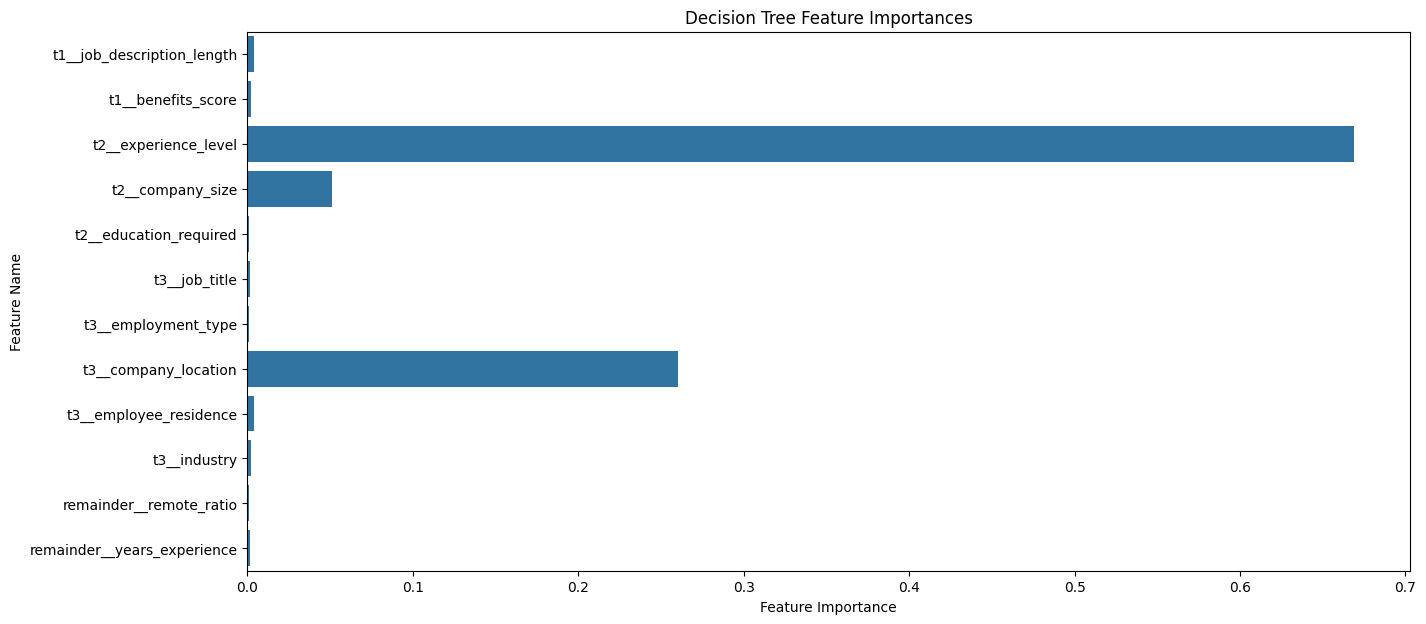

In [ ]:
plt.figure(figsize=(15,7))
feature_names = dt_model.named_steps['columntransformer'].get_feature_names_out()
sns.barplot(x=dt_feature_importances, y=feature_names)
plt.title('Decision Tree Feature Importances')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.show()

In [ ]:
dt_feature_importances = dt_model.named_steps['decisiontreeregressor'].feature_importances_
dt_feature_importances

array([0.00385375, 0.00251498, 0.66913505, 0.05139069, 0.00093485,
       0.00164228, 0.00126342, 0.26029117, 0.00416754, 0.00220621,
       0.00109468, 0.00150538])